## Notebook 5 — Model Explainability with SHAP

Building a model that predicts credit default is only half the job.
The other half is being able to explain WHY the model made a specific
prediction. In regulated industries like banking and fintech, this
explainability is not optional — it is a legal requirement in most
countries under fair lending laws.

I used SHAP (SHapley Additive exPlanations) which is based on game
theory and provides mathematically rigorous explanations for each
prediction. Unlike simple feature importance, SHAP tells us both
which features matter AND in which direction they push the prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model dan data
xgb_model = joblib.load('../models/xgboost_credit_risk.pkl')
df = pd.read_csv('../data/credit_clean.csv')

# Recreate test set dengan split yang sama
from sklearn.model_selection import train_test_split

cols_to_drop = ['TARGET']
optional_cols = ['INCOME_BRACKET', 'AGE_GROUP', 'CREDIT_INCOME_RATIO']
for col in optional_cols:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Test set: {X_test.shape[0]:,} applications")
print("Model and data loaded successfully!")

Test set: 61,502 applications
Model and data loaded successfully!


In [3]:
# SHAP explainer untuk XGBoost
print("Calculating SHAP values...")

explainer = shap.TreeExplainer(xgb_model)

# Use sample of 1000 for speed
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")
print(f"Shape: {shap_values.shape}")

Calculating SHAP values...
SHAP values calculated!
Shape: (1000, 171)


## Calculating SHAP Values

I calculated SHAP values for a random sample of 1,000 test applicants.
Each SHAP value represents how much a specific feature pushed the
prediction higher or lower compared to the average prediction across
all applicants.

A positive SHAP value means the feature increased the predicted
default probability for that applicant. A negative SHAP value means
it decreased the risk. The magnitude tells us how strong that push was.

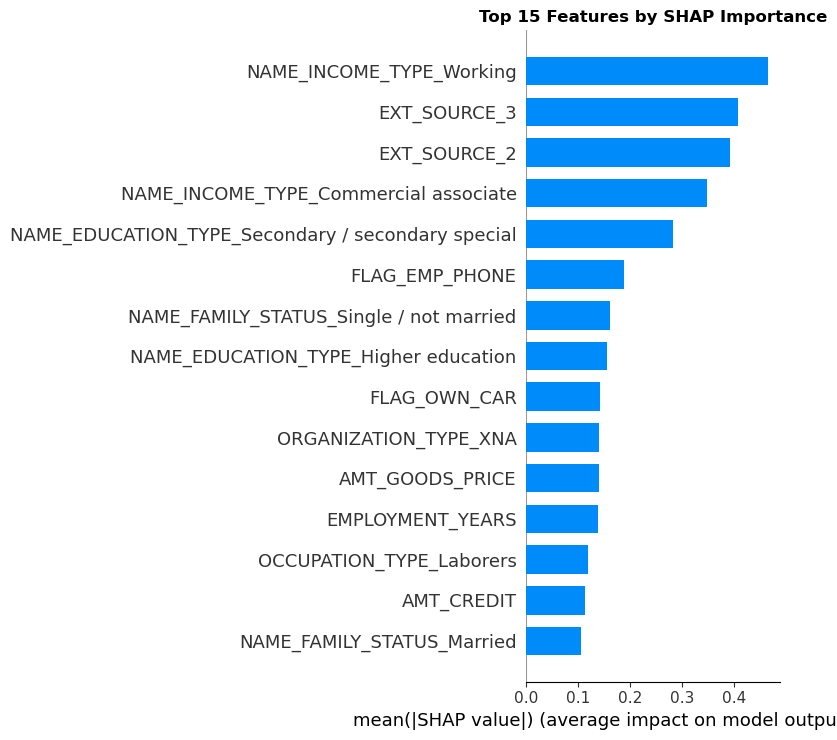

Chart 7 saved


In [4]:
# Global feature importance - which features matter most overall
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 Features by SHAP Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/07_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

## Chart 7 — Global Feature Importance

The top 15 features by SHAP importance reveal something I did not
fully expect. NAME_INCOME_TYPE_Working is the most impactful feature,
followed closely by EXT_SOURCE_3 and EXT_SOURCE_2.

This tells me that whether someone is classified as a "working" income
type has the largest average impact on the model's predictions across
all applicants. The external credit scores come in second and third,
confirming their strong predictive power that we first noticed in the
correlation analysis.

What's interesting is that income type, education type, and family
status all appear in the top 15 — suggesting that demographic and
employment context matters almost as much as formal credit scores
for predicting default risk in this dataset.

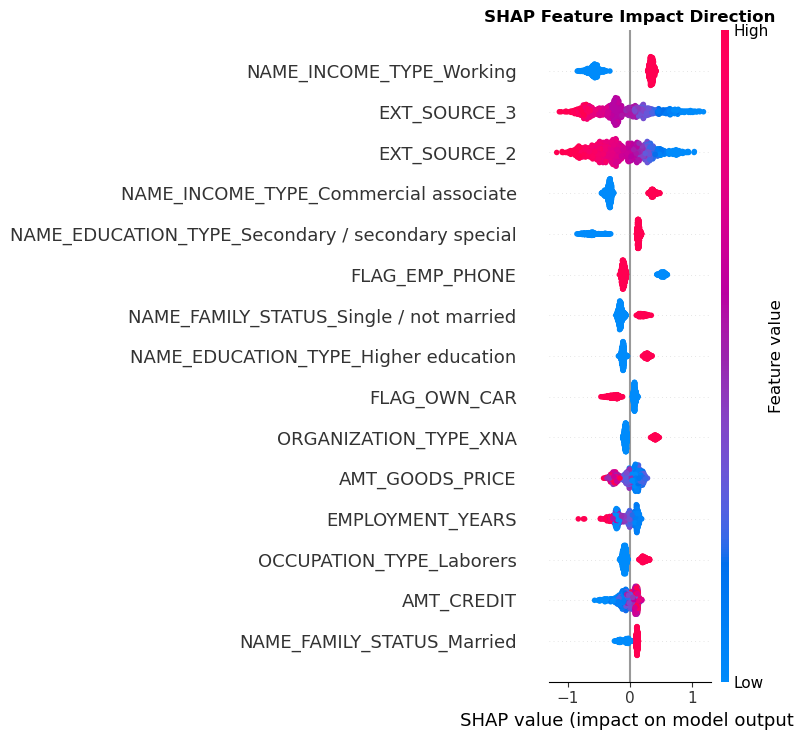

Chart 8 saved


In [8]:
# Beeswarm plot - shows direction of impact too
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/08_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

## Chart 8 — SHAP Beeswarm Plot

The beeswarm plot adds a crucial dimension that the bar chart misses
— it shows the direction of each feature's impact.

For EXT_SOURCE_2 and EXT_SOURCE_3, high values (shown in red) push
the prediction toward lower default risk, while low values (blue)
push toward higher risk. This confirms the intuition that higher
external credit scores protect against default.

For NAME_INCOME_TYPE_Working, the pattern is more nuanced — being
classified as a working income type can push the prediction in both
directions depending on the combination with other features. This
suggests the model has learned complex interaction patterns between
income type and other variables that a simple correlation analysis
would miss entirely.

In [6]:
# Pick a high-risk applicant and explain why
high_risk_idx = X_sample[
    xgb_model.predict_proba(X_sample)[:, 1] > 0.5
].index[0]

high_risk_app = X_sample.loc[[high_risk_idx]]
default_prob = xgb_model.predict_proba(high_risk_app)[0, 1]

print(f"Applicant default probability: {default_prob:.2%}")
print(f"\nKey features for this applicant:")
print(f"EXT_SOURCE_2: {high_risk_app['EXT_SOURCE_2'].values[0]:.3f}")
print(f"EXT_SOURCE_3: {high_risk_app['EXT_SOURCE_3'].values[0]:.3f}")
print(f"AGE_YEARS: {high_risk_app['AGE_YEARS'].values[0]:.1f}")
print(f"EMPLOYMENT_YEARS: {high_risk_app['EMPLOYMENT_YEARS'].values[0]:.1f}")
print(f"AMT_CREDIT: {high_risk_app['AMT_CREDIT'].values[0]:,.0f}")

Applicant default probability: 62.68%

Key features for this applicant:
EXT_SOURCE_2: 0.254
EXT_SOURCE_3: 0.535
AGE_YEARS: 41.2
EMPLOYMENT_YEARS: 1.9
AMT_CREDIT: 195,543


## Individual Prediction Analysis

I selected a high-risk applicant with a predicted default probability
of 62.68% to understand what specifically makes the model flag them
as risky.

Looking at their profile: EXT_SOURCE_2 of only 0.254 is well below
the dataset average of 0.51, suggesting their external credit history
is poor. Despite being 41 years old which should indicate financial
maturity, their employment duration of only 1.9 years signals recent
job instability. The combination of low credit scores and short
employment history is exactly the profile a lender should scrutinize
carefully before approving.

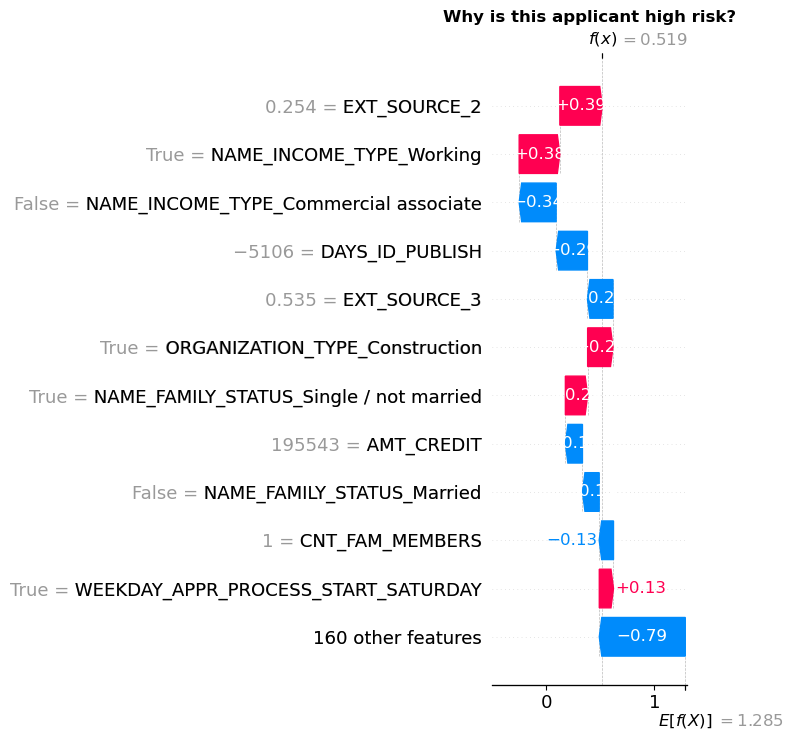

Chart 9 saved


In [7]:
# Waterfall chart showing why this specific person is high risk
shap_single = explainer.shap_values(high_risk_app)

shap_explanation = shap.Explanation(
    values=shap_single[0],
    base_values=explainer.expected_value,
    data=high_risk_app.values[0],
    feature_names=X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title('Why is this applicant high risk?', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved")

## Chart 9 — SHAP Waterfall Plot

The waterfall chart is the most powerful output of this entire project
because it answers the question a loan officer actually asks: "Why did
the model flag this specific person as high risk?"

Each bar shows one feature's contribution to pushing the prediction
away from the base rate (the average default probability across all
applicants). Red bars push the prediction higher toward default, blue
bars push it lower toward safe.

This level of explainability is what regulators require under fair
lending laws. A credit decision cannot simply say "the algorithm said
no" — it must be able to articulate specific risk factors. This
waterfall chart provides exactly that audit trail, making the model
not just accurate but deployable in a real regulatory environment.